# Exploratory Analysis: Mortgage Credit Stress Testing

The first cell transforms the modelling data and uses it for
further exploratory analysis. The outputs of the EDA is then
used for plotting in later cells

In [2]:
import glob
import os
from functools import reduce

from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, col, count, date_format, to_date, when

spark = SparkSession.builder.appName("CreditRiskEDA").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

def create_eda_outputs(modeling_df):
    """
    QUESTION ANSWERED:
    What patterns in the portfolio should be understood before training the model?
    """


    # How many records are in each delinquency status?
    delinquency_counts = modeling_df.groupBy("current_loan_delinquency") \
        .count() \
        .orderBy("current_loan_delinquency")

    delinquency_counts.show()
    delinquency_counts.coalesce(1).write.mode("overwrite") \
        .option("header", "true") \
        .csv("outputs/eda/delinquency_counts")

    # How does the portfolio move between risk states over time?
    risk_state_by_month = modeling_df.groupBy("reporting_month", "risk_state") \
        .count() \
        .orderBy("reporting_month", "risk_state")

    risk_state_by_month.coalesce(1).write.mode("overwrite") \
        .option("header", "true") \
        .csv("outputs/eda/risk_state_by_month")

    # Which states contain the largest number of mortgage records?
    portfolio_by_state = modeling_df.groupBy("property_state") \
        .count() \
        .orderBy(col("count").desc())

    portfolio_by_state.show()
    portfolio_by_state.coalesce(1).write.mode("overwrite") \
        .option("header", "true") \
        .csv("outputs/eda/portfolio_by_state")

    # How does serious delinquency vary by credit score band?
    credit_score_risk = modeling_df.groupBy("credit_score_band") \
        .agg(count("*").alias("loan_records"),
            avg("is_seriously_delinquent").alias("serious_delinquency_rate"))\
                .orderBy("credit_score_band")

    credit_score_risk.coalesce(1).write.mode("overwrite") \
        .option("header", "true") \
        .csv("outputs/eda/credit_score_band_delinquency")

    # How does serious delinquency vary by original LTV band?
    ltv_risk = modeling_df.groupBy("ltv_band") \
        .agg(
            count("*").alias("loan_records"),
            avg("is_seriously_delinquent").alias("serious_delinquency_rate"),
        ) \
        .orderBy("ltv_band")

    ltv_risk.coalesce(1).write.mode("overwrite") \
        .option("header", "true") \
        .csv("outputs/eda/ltv_band_delinquency")

    # Save the monthly macro data so it can be graphed in the notebook.
    # fred_2025.coalesce(1).write.mode("overwrite") \
    #     .option("header", "true") \
    #     .csv("outputs/eda/fred_2025")

    # Spark SQL question:
    # By month, how large is the portfolio and what is its serious delinquency rate?
    modeling_df.createOrReplaceTempView("mortgage_portfolio")

    monthly_portfolio_summary = spark.sql("""
        SELECT
            reporting_month,
            COUNT(*) AS loan_records,
            SUM(current_actual_upb) AS total_current_upb,
            AVG(borrower_credit_score) AS average_credit_score,
            AVG(original_ltv) AS average_original_ltv,
            AVG(is_seriously_delinquent) AS serious_delinquency_rate
        FROM mortgage_portfolio
        GROUP BY reporting_month
        ORDER BY reporting_month
    """)

    monthly_portfolio_summary.show(truncate=False)
    monthly_portfolio_summary.coalesce(1).write.mode("overwrite") \
        .option("header", "true") \
        .csv("outputs/sql/monthly_portfolio_summary")
    
fred_2025 = spark.read.option("header", True).csv("../outputs/fred_2025.csv")
modeling_df = spark.read.parquet("../data/processed/modeling_base.parquet")
    
create_eda_outputs(modeling_df)

+------------------------+-------+
|current_loan_delinquency|  count|
+------------------------+-------+
|                       0|5805022|
|                       1|  29738|
|                       2|   4984|
|                       3|   1933|
|                       4|    991|
|                       5|    610|
|                       6|    387|
|                       7|    231|
|                       8|    120|
|                       9|     57|
|                      10|     33|
|                      11|     18|
|                      12|      4|
+------------------------+-------+

+--------------+------+
|property_state| count|
+--------------+------+
|            TX|586371|
|            CA|452745|
|            FL|387749|
|            IL|251260|
|            NC|232594|
|            OH|225717|
|            NY|204811|
|            GA|199983|
|            MI|198901|
|            PA|198758|
|            AZ|172062|
|            WA|160356|
|            IN|159869|
|            CO|1538

In [3]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

def read_spark_csv_folder(path):
    files = glob.glob(os.path.join(path, 'part-*.csv'))
    if not files:
        raise FileNotFoundError(f'No Spark CSV part file found in {path}')
    return pd.read_csv(files[0])


## 1. Delinquency Distribution

This chart shows how many loan records are current, 30 days delinquent, 60 days delinquent, or 90+ days delinquent. It gives a quick sense of the portfolio's credit quality.

,current_loan_delinquency,count
0,0,5805022
1,1,29738
2,2,4984
3,3,1933
4,4,991
5,5,610
6,6,387
7,7,231
8,8,120
9,9,57


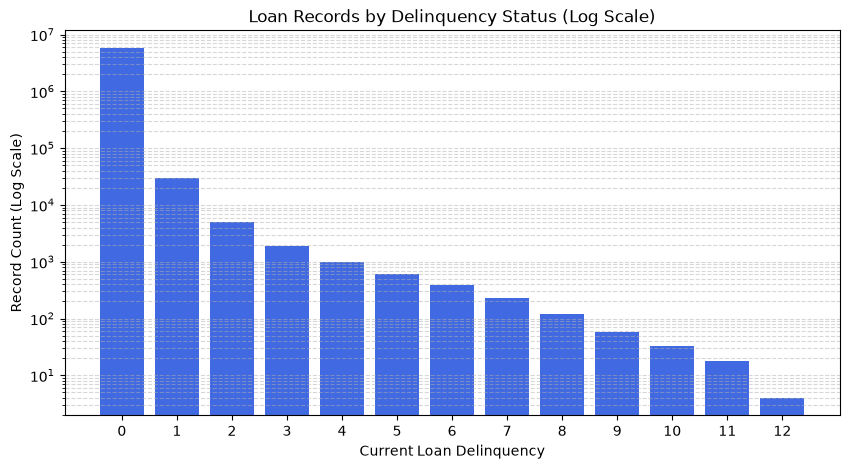

In [ ]:
import matplotlib.pyplot as plt

# 1. Convert Spark DataFrame to Pandas for local plotting
delinq = read_spark_csv_folder('outputs/eda/delinquency_counts')

display(delinq)

# 2. Sort by the delinquency status so your bars go from 1 to 12 in order
df_pandas = delinq.sort_values('current_loan_delinquency')

plt.figure(figsize=(10, 5))

# Plot the bars
plt.bar(df_pandas['current_loan_delinquency'].astype(str), df_pandas['count'], color='royalblue')

# Set Y-axis to log scale 
plt.yscale('log')

plt.title('Loan Records by Delinquency Status (Log Scale)')
plt.xlabel('Current Loan Delinquency')
plt.ylabel('Record Count (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.5, which='both') # 'which=both' shows major and minor log gridlines

plt.show()



## 2. Risk State Over Time

This view shows how the portfolio changes by reporting month. A good story to tell here is whether serious delinquency is stable, rising, or concentrated in a few months.

,reporting_month,risk_state,count
0,2025-01,30 DPD,149
1,2025-01,Current,70178
2,2025-02,30 DPD,665
3,2025-02,60 DPD,20
4,2025-02,Current,125695


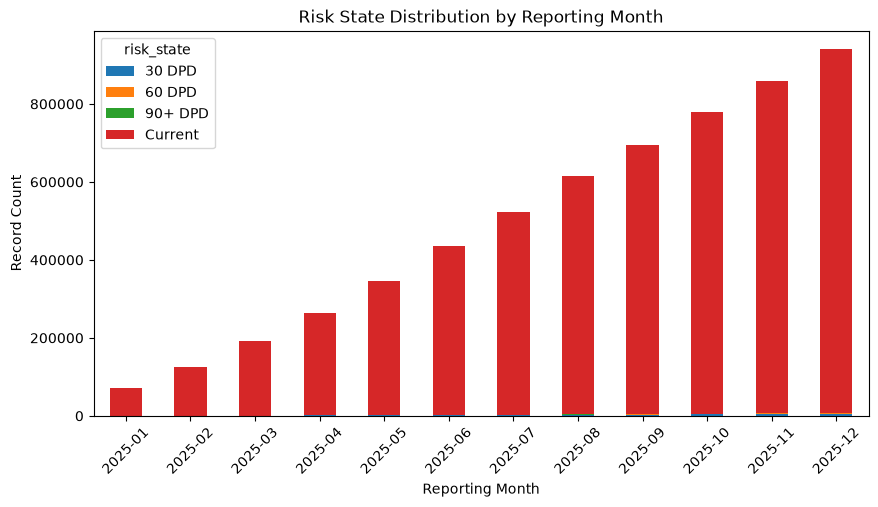

In [6]:
risk_month = read_spark_csv_folder('outputs/eda/risk_state_by_month')
display(risk_month.head())

pivot = risk_month.pivot_table(index='reporting_month', columns='risk_state', values='count', fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Risk State Distribution by Reporting Month')
plt.xlabel('Reporting Month')
plt.ylabel('Record Count')
plt.xticks(rotation=45)
plt.show()


## 3. Credit Score Band and Serious Delinquency

This chart connects borrower credit quality to serious delinquency. It helps explain why credit score is a useful model feature.

,credit_score_band,loan_records,serious_delinquency_rate
0,Excellent,3366843,0.000200
1,Fair,420006,0.003729
2,Good,705872,0.001693
3,Missing,17122,0.000818
4,Poor,10039,0.003287
5,Very Good,1324246,0.000682


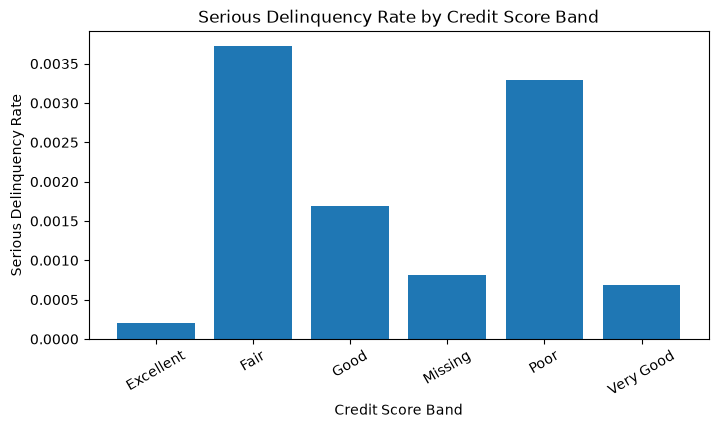

In [7]:
credit = read_spark_csv_folder('outputs/eda/credit_score_band_delinquency')
display(credit)

plt.figure(figsize=(8, 4))
plt.bar(credit['credit_score_band'], credit['serious_delinquency_rate'])
plt.title('Serious Delinquency Rate by Credit Score Band')
plt.xlabel('Credit Score Band')
plt.ylabel('Serious Delinquency Rate')
plt.xticks(rotation=30)
plt.show()


## 4. LTV Band and Serious Delinquency

LTV is important in mortgage risk because higher-LTV loans may have less borrower equity. This chart helps show whether that pattern appears in the data.

,ltv_band,loan_records,serious_delinquency_rate
0,61-80,2393580,0.000584
1,81-90,757298,0.000732
2,91-97,1307946,0.001161
3,<=60,1385304,0.000660


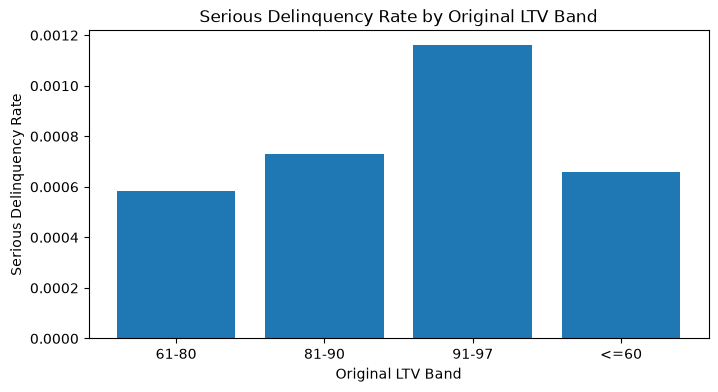

In [8]:
ltv = read_spark_csv_folder('outputs/eda/ltv_band_delinquency')
display(ltv)

plt.figure(figsize=(8, 4))
plt.bar(ltv['ltv_band'], ltv['serious_delinquency_rate'])
plt.title('Serious Delinquency Rate by Original LTV Band')
plt.xlabel('Original LTV Band')
plt.ylabel('Serious Delinquency Rate')
plt.show()


## 5. Transition Matrix

The transition matrix shows loan migration from one risk state to the next. This is one of the strongest credit-risk parts of the project.

,from_state,30 DPD,60 DPD,90+ DPD,Current
0,30 DPD,0.228191,0.162858,0.001860,0.607091
1,60 DPD,0.093960,0.205101,0.457450,0.243490
2,90+ DPD,0.016883,0.034091,0.839935,0.109091
3,Current,0.004437,0.000036,0.000010,0.995517


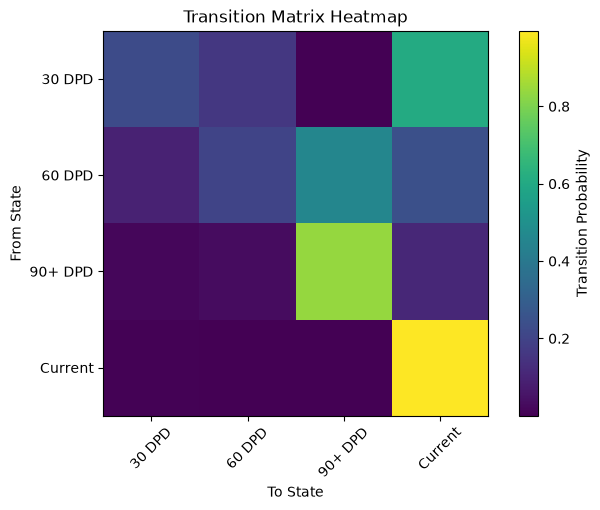

In [10]:
transition = read_spark_csv_folder('../outputs/TM/transition_matrix_pivot')
display(transition)

transition_plot = transition.set_index('from_state')
plt.figure(figsize=(8, 5))
plt.imshow(transition_plot.fillna(0))
plt.title('Transition Matrix Heatmap')
plt.xlabel('To State')
plt.ylabel('From State')
plt.xticks(range(len(transition_plot.columns)), transition_plot.columns, rotation=45)
plt.yticks(range(len(transition_plot.index)), transition_plot.index)
plt.colorbar(label='Transition Probability')
plt.show()


## 6. Baseline vs Stress Expected Loss

This chart is the main stress testing result. It compares expected loss under the baseline macro conditions and the stressed macro assumptions.

## 7. Model Metrics

The MLlib model metrics are stored in JSON. Use these values in the final report and slides.

In [11]:
import json

with open('../outputs/ML/model_metrics.json', 'r') as file:
    metrics = json.load(file)

metrics


{'model_type': 'Spark MLlib Logistic Regression',
 'label': 'is_seriously_delinquent',
 'train_rows': 438832,
 'test_rows': 146409,
 'area_under_curve': 0.8302298874146381,
 'accuracy': 0.9991803782554352,
 'weighted_precision': 0.9983614282906745,
 'lgd_method': 'Simple LTV-based LGD proxy; UPB is used as EAD'}